# **Drug Response Classification** 

## Knowledge about DATA Set

- Business Context
1) Pharmaceutical companies invest millions of dollars in clinical trials to test drug efficacy. However, some drugs do not work for all patients due to individual differences in biology, metabolism, and pre-existing conditions.
2) Traditional clinical trials take years to conclude, with high costs and risks.
3) Machine learning models can help predict drug response early, saving time and resources.
4) Personalized medicine ensures that patients receive the right drug at the right dose.

(0 = No response, 1 = Positive response)

Drug response classification refers to how a patient’s body **reacts to a particular drug**. This is a key concept in **pharmaceutical research** and **clinical trials**, where researchers analyze whether a drug is **effective or not** based on biological responses.

 Interpretation of Classification Labels:

---

 *1. **0 = No Response***

- The drug **did not have a significant effect** on the patient.
- The patient’s condition **remained unchanged** after taking the drug.
- The biomarkers (e.g., blood pressure, glucose level, heart rate) **did not improve**.
- **Possible reasons:**
  - The drug is not suitable for the patient.
  - The dosage is ineffective.
  - The patient's metabolism is resistant to the drug.

---

 *2. **1 = Positive Response***

- The drug **had a beneficial effect** on the patient.
- The patient’s condition **improved** after taking the drug.
- Biomarkers such as blood pressure, glucose levels, and enzyme activity **show significant improvement**.
- **Possible reasons:**
  - The drug is effective for this patient.
  - The dosage is appropriate.
  - The patient’s metabolism responds well to the drug.

---

*Why is This Classification Important?*

- **Pharmaceutical Industry:** Used to test new drugs and evaluate their effectiveness before FDA approval.

- **Personalized Medicine:** Helps doctors prescribe drugs based on individual patient responses.

- **Machine Learning in Healthcare:** Enables predictive models to **forecast patient responses** based on medical data.

---

*Feature Descriptions*

| **Revised Business-Oriented Name** | **Business Context** |
|-----------------------------------|-----------------------|
| **Drug Dosage (mg)** | Amount of the drug administered to the patient (measured in milligrams). |
| **Systolic Blood Pressure (mmHg)** | Patient’s systolic blood pressure, indicating cardiovascular response to the drug. |
| **Heart Rate (BPM)** | Patient’s heart rate (beats per minute), important for monitoring cardiovascular effects. |
| **Liver Toxicity Index (U/L)** | Liver enzyme levels, indicating potential side effects or toxicity from the drug. |
| **Blood Glucose Level (mg/dL)** | Blood sugar level, critical for drugs affecting metabolism (e.g., diabetes medications). |
| **Drug Response (0 = No Response, 1 = Positive Response)** | Whether the drug was effective for the patient or not. |


## Imoporating Libraries and dataset

In [124]:
# Step 1: imports and load
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
from sklearn.decomposition import PCA

# Optional for imbalance handling
# from imblearn.over_sampling import SMOTE
# from imblearn.pipeline import Pipeline as ImbPipeling

In [125]:
DATA_PATH = "Pharma_Industry.csv"
df = pd.read_csv(DATA_PATH)

# Quick checks
print("Shape:", df.shape)
print("Columns:\n", df.columns.tolist())

Shape: (500, 6)
Columns:
 ['Drug Dosage (mg)', 'Systolic Blood Pressure (mmHg)', 'Heart Rate (BPM)', 'Liver Toxicity Index (U/L)', 'Blood Glucose Level (mg/dL)', 'Drug Response']


In [126]:
display(df.head())

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


In [127]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


None

In [128]:
display(df.shape)

(500, 6)

In [129]:
display(df.isna().sum().sort_values(ascending=False).head(20))

Drug Dosage (mg)                  0
Systolic Blood Pressure (mmHg)    0
Heart Rate (BPM)                  0
Liver Toxicity Index (U/L)        0
Blood Glucose Level (mg/dL)       0
Drug Response                     0
dtype: int64

## **Exploratory Data Analysis (EDA)**

In [130]:
# Target distribution
target_col = 'Drug Response'  # change to actual column name if different
print(df[target_col].value_counts(dropna=False))
print(df[target_col].value_counts(normalize=True))

Drug Response
1    260
0    240
Name: count, dtype: int64
Drug Response
1    0.52
0    0.48
Name: proportion, dtype: float64


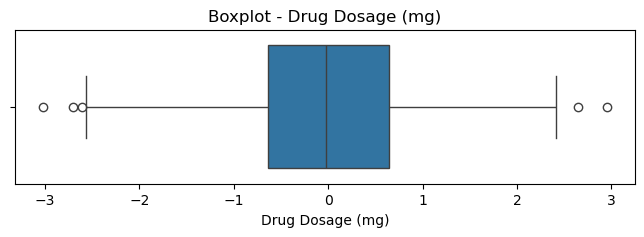

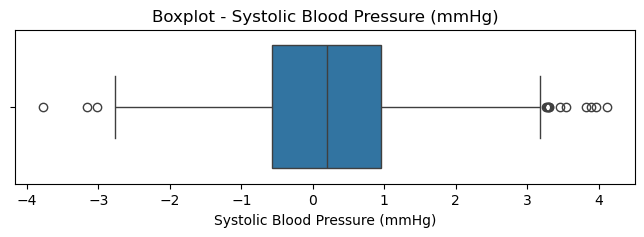

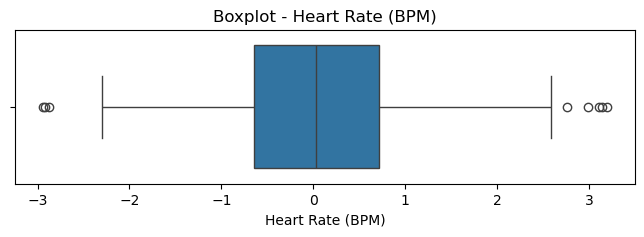

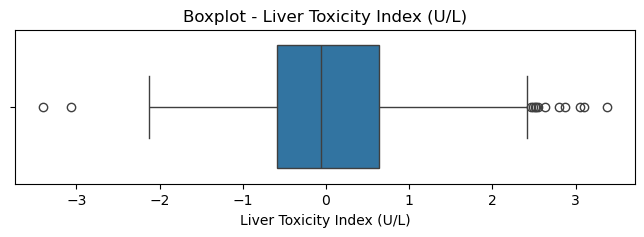

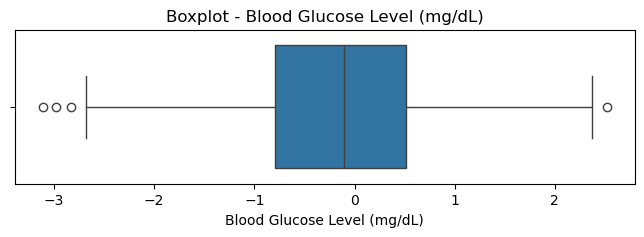

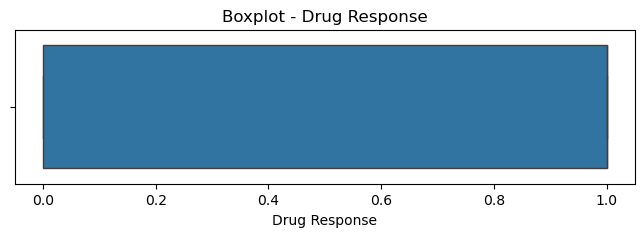

In [131]:
# Outlier detection (visual and z-score based)
# Display boxplots for numeric columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in num_cols:
    plt.figure(figsize=(8, 2))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot - {col}')
    plt.show()

In [132]:
# Z-score method to flag extreme outliers (|z| > 3)
z_scores = np.abs(stats.zscore(df[num_cols], nan_policy='omit'))
outlier_mask = (z_scores > 3)
# Count outliers per column:
outlier_counts = pd.DataFrame(outlier_mask, columns=num_cols).sum().sort_values(ascending=False)
display(outlier_counts)

Heart Rate (BPM)                  7
Liver Toxicity Index (U/L)        5
Systolic Blood Pressure (mmHg)    3
Drug Dosage (mg)                  2
Blood Glucose Level (mg/dL)       0
Drug Response                     0
dtype: int64

In [133]:
# Handling outliers by capping (winsorization) at 1st and 99th percentiles
def winsorize_series(s, lower_pct=0.01, upper_pct=0.99):
    lower = s.quantile(lower_pct)
    upper = s.quantile(upper_pct)
    return s.clip(lower, upper)

for col in num_cols:
    df[col] = winsorize_series(df[col], 0.01, 0.99)

In [134]:
# Z-score method to flag extreme outliers (|z| > 3)
z_scores = np.abs(stats.zscore(df[num_cols], nan_policy='omit'))
outlier_mask = (z_scores > 3)
# Count outliers per column:
outlier_counts = pd.DataFrame(outlier_mask, columns=num_cols).sum().sort_values(ascending=False)
display(outlier_counts)

Drug Dosage (mg)                  0
Systolic Blood Pressure (mmHg)    0
Heart Rate (BPM)                  0
Liver Toxicity Index (U/L)        0
Blood Glucose Level (mg/dL)       0
Drug Response                     0
dtype: int64

In [135]:
# Summary statistics
display(df[num_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
Drug Dosage (mg),500.0,-0.039129,0.963824,-2.439732,-0.642003,-0.019340,0.641151,2.074339
Systolic Blood Pressure (mmHg),500.0,0.215746,1.223668,-2.585081,-0.565168,0.201532,0.951375,3.465611
Heart Rate (BPM),500.0,0.064851,0.942351,-2.006017,-0.648157,0.027732,0.710774,2.591265
Liver Toxicity Index (U/L),500.0,0.055825,0.959394,-1.970946,-0.586085,-0.065661,0.633914,2.634192
Blood Glucose Level (mg/dL),500.0,-0.172655,0.969057,-2.600987,-0.797715,-0.108106,0.513555,1.860015
Drug Response,500.0,0.520000,0.500100,0.000000,0.000000,1.000000,1.000000,1.000000


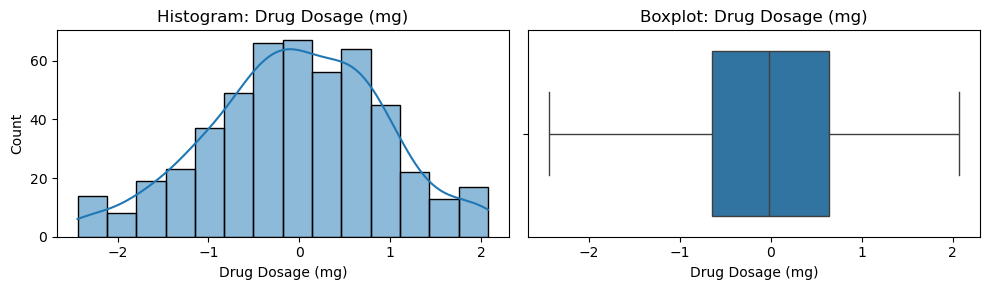

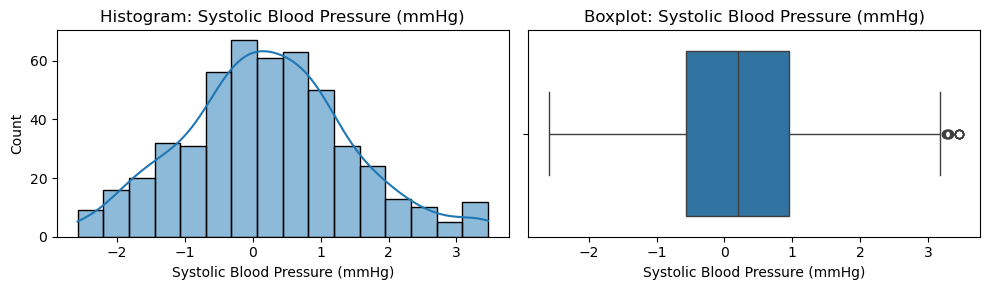

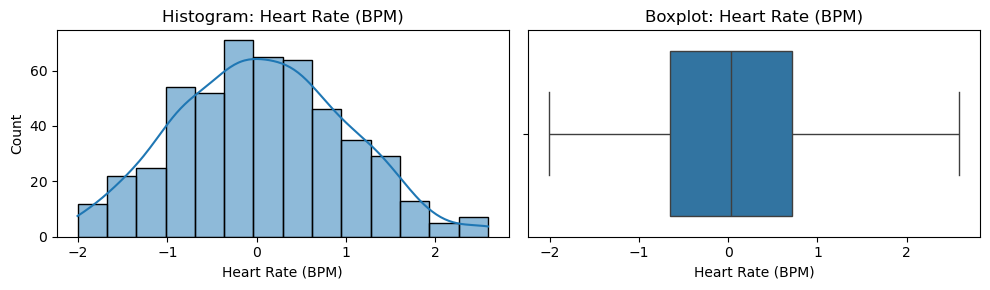

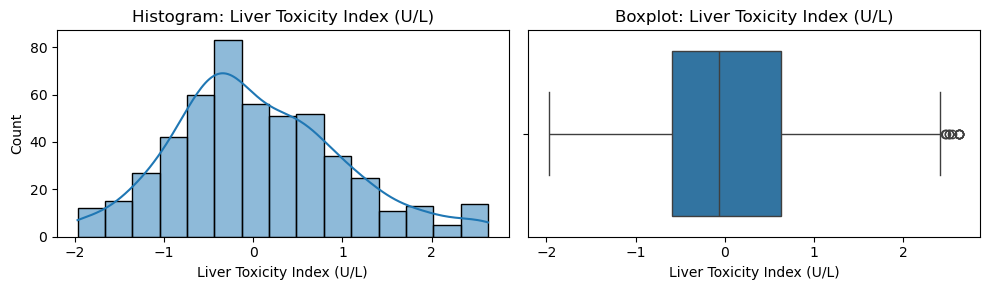

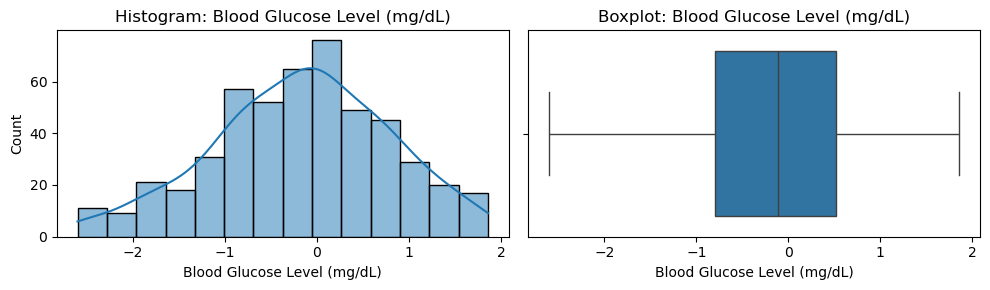

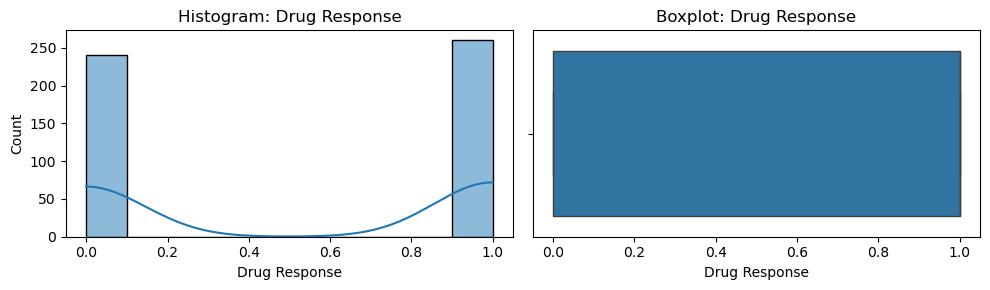

In [136]:
# Histograms and boxplots for numeric features
for col in num_cols:
    plt.figure(figsize=(10,3))
    plt.subplot(1,2,1)
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f"Histogram: {col}")
    plt.subplot(1,2,2)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot: {col}")
    plt.tight_layout()
    plt.show()

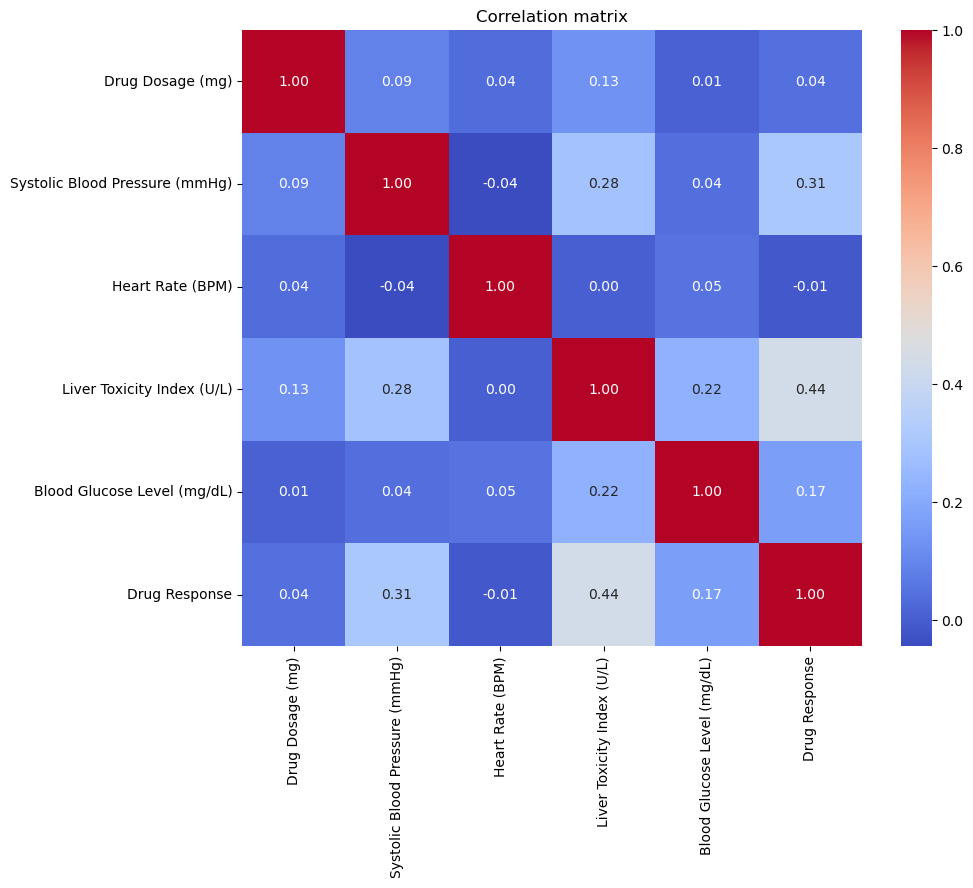

In [137]:
# Correlation heatmap (numeric only)
plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation matrix")
plt.show()

### *Preprocessing: missing values, categorical encoding, scaling*

- Theory:

1) Numeric missing values: impute (mean/median) or model-based imputation.
2) Categorical missing values: impute with mode or "Missing".
3) Categorical variables: encode with OneHotEncoder (if few categories) or Ordinal encoding if ordered.
4) Scale numeric features for models like logistic regression (standardize to mean 0, sd 1).

In [138]:
# Identify feature types
cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()
num_cols = [c for c in df.columns if c not in cat_cols + ['Drug Response']]

print("Numeric:", num_cols)
print("Categorical:", cat_cols)

# Build preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),   # use median to be robust to outliers
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
], remainder='drop')


Numeric: ['Drug Dosage (mg)', 'Systolic Blood Pressure (mmHg)', 'Heart Rate (BPM)', 'Liver Toxicity Index (U/L)', 'Blood Glucose Level (mg/dL)']
Categorical: []


## *Train/test split and resampling*

In [139]:
# train-test split
X = df.drop(columns=[target_col])
y = df[target_col].astype(int)  # ensure integer type

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape, "Test size:", X_test.shape)

# If training classes are imbalanced, show distribution
print("Train class distribution:\n", y_train.value_counts(normalize=True))


Train size: (400, 5) Test size: (100, 5)
Train class distribution:
 Drug Response
1    0.52
0    0.48
Name: proportion, dtype: float64


In [140]:
# pipeline that first preprocesses then applies SMOTE (using imblearn pipeline)
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

clf = RandomForestClassifier(random_state=42, n_jobs=-1)

imb_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('clf', clf)
])

# Fit
imb_pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Drug Dosage (mg)',
                                                   'Systolic Blood Pressure '
                                                   '(mmHg)',
                                                   'Heart Rate (BPM)',
                                                   'Liver Toxicity Index (U/L)',
                                                   'Blood Glucose Level '
                                                   '(mg/dL)']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  [])])),
                ('smote', SMOTE(random_state=42)),
                ('clf', RandomForestClassifier(n_jobs=-1, random_state=42))])

## *Model training: baseline and improved models*

In [141]:
# Baseline model (Logistic Regression) in a pipeline

pipe_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

pipe_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight='balanced'))
])

# Cross-validated score (use StratifiedKFold)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_lr = cross_val_score(pipe_lr, X_train, y_train, cv=skf, scoring='roc_auc')
cv_scores_rf = cross_val_score(pipe_rf, X_train, y_train, cv=skf, scoring='roc_auc')

print("LR CV ROC AUC: mean {:.3f} (+/-{:.3f})".format(cv_scores_lr.mean(), cv_scores_lr.std()))
print("RF CV ROC AUC: mean {:.3f} (+/-{:.3f})".format(cv_scores_rf.mean(), cv_scores_rf.std()))

# Fit to full training set
pipe_lr.fit(X_train, y_train)
pipe_rf.fit(X_train, y_train)


LR CV ROC AUC: mean 0.778 (+/-0.033)
RF CV ROC AUC: mean 0.837 (+/-0.042)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Drug Dosage (mg)',
                                                   'Systolic Blood Pressure '
                                                   '(mmHg)',
                                                   'Heart Rate (BPM)',
                                                   'Liver Toxicity Index (U/L)',
                                                   'Blood Glucose Level '
                                                   '(mg/dL)']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  [])])),
                ('clf',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, n_jobs=-1,
                                        random_state=42))])

## *Evaluation on test set*

=== Evaluation: LogisticRegression ===
Accuracy: 0.71
Precision: 0.7346938775510204
Recall (sensitivity): 0.6923076923076923
F1-score: 0.7128712871287128
ROC AUC: 0.7892628205128205

Classification report:
               precision    recall  f1-score   support

           0       0.69      0.73      0.71        48
           1       0.73      0.69      0.71        52

    accuracy                           0.71       100
   macro avg       0.71      0.71      0.71       100
weighted avg       0.71      0.71      0.71       100



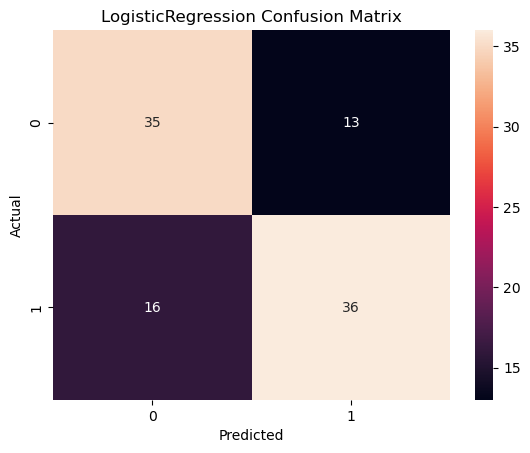

In [142]:
# Evaluate
def evaluate_model(pipeline, X_test, y_test, model_name="model"):
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:,1] if hasattr(pipeline, "predict_proba") else None

    print("=== Evaluation:", model_name, "===")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall (sensitivity):", recall_score(y_test, y_pred))
    print("F1-score:", f1_score(y_test, y_pred))
    if y_proba is not None:
        print("ROC AUC:", roc_auc_score(y_test, y_proba))
    print("\nClassification report:\n", classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title(f"{model_name} Confusion Matrix")
    plt.show()

evaluate_model(pipe_lr, X_test, y_test, "LogisticRegression")

=== Evaluation: RandomForest ===
Accuracy: 0.76
Precision: 0.75
Recall (sensitivity): 0.8076923076923077
F1-score: 0.7777777777777778
ROC AUC: 0.8197115384615384

Classification report:
               precision    recall  f1-score   support

           0       0.77      0.71      0.74        48
           1       0.75      0.81      0.78        52

    accuracy                           0.76       100
   macro avg       0.76      0.76      0.76       100
weighted avg       0.76      0.76      0.76       100



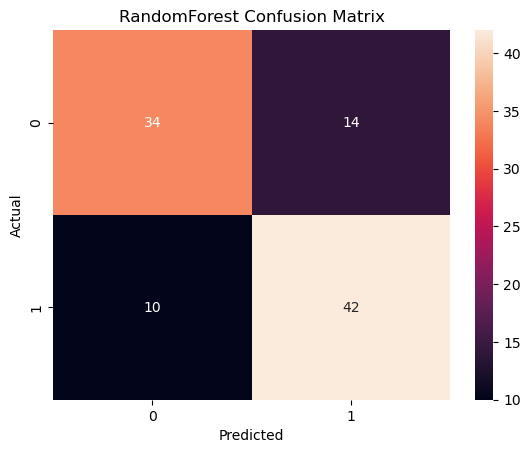

In [143]:
evaluate_model(pipe_rf, X_test, y_test, "RandomForest")

# 📊 Model Evaluation and Interpretation

This section provides a complete interpretation of the Logistic Regression and Random Forest models used for predicting **Drug Response (0 = No Response, 1 = Positive Response)**.

---

## 🔍 1. Logistic Regression – Interpretation

### **Performance Metrics**
- **Accuracy:** 0.71  
- **Precision:** 0.7347  
- **Recall (Sensitivity):** 0.6923  
- **F1-score:** 0.7129  
- **ROC AUC:** 0.7893  

### **Interpretation**
- Logistic Regression achieves **moderate predictive performance**.
- **Precision (0.73)** indicates that when the model predicts a positive drug response, it is correct 73% of the time.
- **Recall is lower (0.69)**, meaning the model misses several patients who would actually respond positively to the drug.
- **F1-score (0.71)** shows a reasonable balance between precision and recall.
- **ROC AUC (0.789)** suggests the model is reasonably capable of distinguishing responders from non-responders.

### **Confusion Matrix Insights**
- False Negatives are relatively high (16), meaning:
  - Several patients who *would* respond positively are incorrectly predicted as non-responders.
- This contributes to the lower recall.

### **Conclusion (Logistic Regression)**
- ✔ Good interpretability  
- ✔ Stable baseline performance  
- ✖ Misses many true responders  
- ➤ Best used when **interpretability is more important than prediction power**  

---

## 🌲 2. Random Forest – Interpretation

### **Performance Metrics**
- **Accuracy:** 0.76  
- **Precision:** 0.75  
- **Recall (Sensitivity):** 0.8077  
- **F1-score:** 0.7778  
- **ROC AUC:** 0.8197  

### **Interpretation**
- Random Forest performs **better across all major metrics**.
- **Recall (0.81)** is significantly higher than Logistic Regression:
  - The model successfully identifies most true responders.
- **F1-score (0.78)** indicates stronger overall classification performance.
- **ROC AUC (0.82)** shows improved discrimination ability.
- The model captures **non-linear relationships** between physiological variables and drug response that Logistic Regression cannot.

### **Confusion Matrix Insights**
- False Negatives decrease sharply (from 16 → 10).
- This is crucial in healthcare applications, where missing a likely responder is risky.
- False Positives increase slightly but remain balanced.

### **Conclusion (Random Forest)**
- ✔ Best model overall  
- ✔ Highest accuracy and recall  
- ✔ Captures complex patient response patterns  
- ➤ Suitable for real-world prediction and clinical decision support  

---

## 🏁 Final Comparative Insights

| Metric | Logistic Regression | Random Forest | Better Model |
|--------|---------------------|--------------|--------------|
| Accuracy | 0.71 | **0.76** | RF |
| Precision | 0.73 | **0.75** | RF |
| Recall | 0.69 | **0.81** | RF |
| F1-score | 0.71 | **0.78** | RF |
| ROC AUC | 0.79 | **0.82** | RF |

**Overall Winner: _Random Forest_**

---

## 🧪 Final Notes

Random Forest is the superior model for predicting drug response due to:
- Higher recall (critical in healthcare)
- Better F1-score
- Stronger discrimination capability
- Ability to model non-linear interactions

Logistic Regression remains useful when:
- Interpretability is crucial  
- Simpler linear relationships are sufficient

